# Preprocessing Lung Sounds

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)

from matplotlib import pyplot as plt

from modules.dataset import ICBHIDataset, KAUHDataset, CombinedLungSoundDataset, LungSoundDataset
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    # "Bronchitis",
    "COPD",
    "Healthy",
    # "Heart Failure",
    # "LRTI",
    "Lung Fibrosis",
    # "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [3]:
# Example of a transformation pipeline that can be applied to the audio data
data_transforms = Compose([
    Spectrogram(n_fft=2048, hop_length=512),
])

In [4]:
def plot_label_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of labels in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset containing label information.
    """
    data = dataset.data
    label_counts = data["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

ICBHI Dataset size: 3893 samples


Diagnosis
COPD              3400
Pneumonia          148
Healthy            135
URTI                90
Bronchiectasis      64
Bronchiolitis       52
Asthma               4
Name: count, dtype: int64

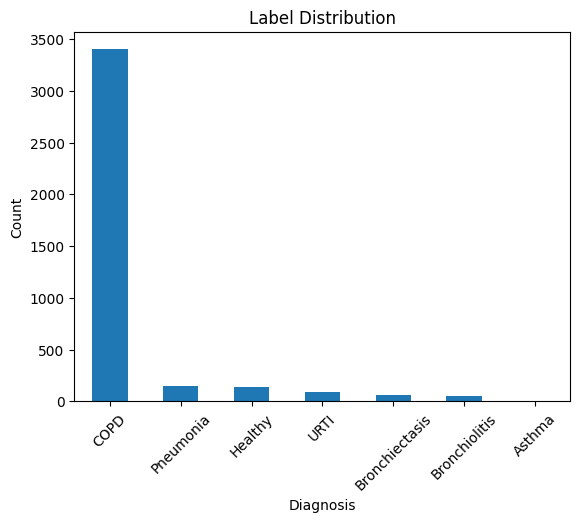

In [5]:
icbhi_dataset = ICBHIDataset(DATA_FOLDER, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"ICBHI Dataset size: {len(icbhi_dataset)} samples")
plot_label_distribution(icbhi_dataset)

KAUH Dataset size: 763 samples


Diagnosis
Healthy          313
Asthma           279
COPD              87
Pneumonia         51
Lung Fibrosis     33
Name: count, dtype: int64

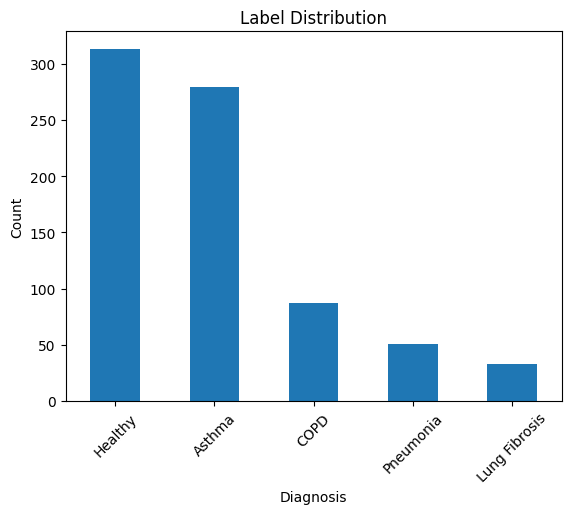

In [6]:
kauh_dataset = KAUHDataset(DATA_FOLDER, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"KAUH Dataset size: {len(kauh_dataset)} samples")
plot_label_distribution(kauh_dataset)

Dataset size: 4656 samples


Diagnosis
COPD              3487
Healthy            448
Asthma             283
Pneumonia          199
URTI                90
Bronchiectasis      64
Bronchiolitis       52
Lung Fibrosis       33
Name: count, dtype: int64

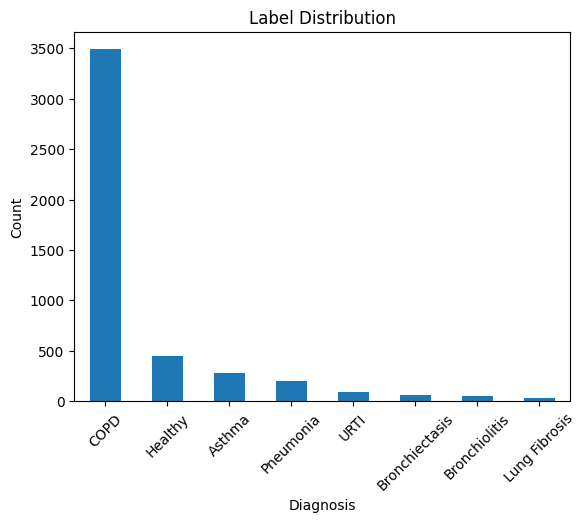

In [7]:
combined_dataset = CombinedLungSoundDataset(DATA_FOLDER, "all", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Dataset size: {len(combined_dataset)} samples")
plot_label_distribution(combined_dataset)

Sample 0:
  File name: 101_1b1_Al_sc_Meditron_start0_end5.wav
  Label: 7 (URTI)
  Sample rate: 22050
  Audio shape: (110250,)


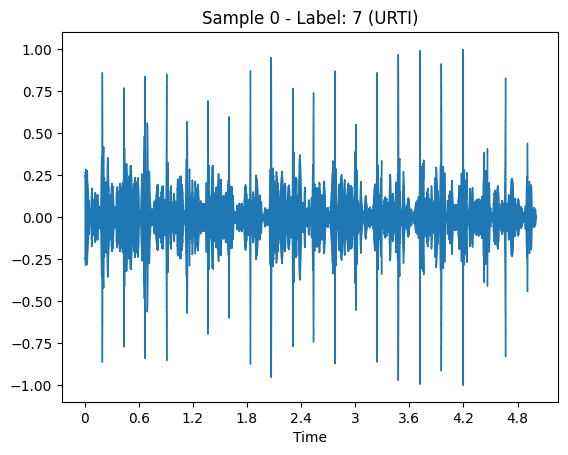

  Features shape: (1025, 216)
  Features dimensions: 2
  Features dtype: float32


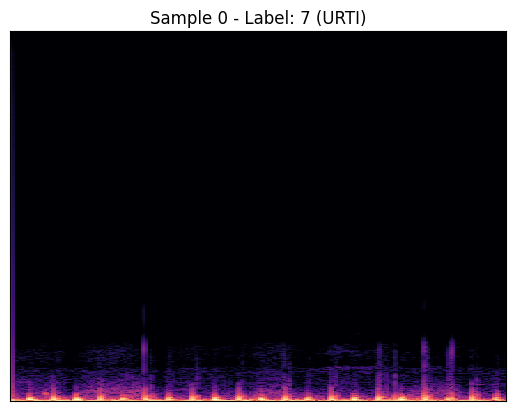

In [8]:
combined_dataset.unit_test(idx=0)

In [9]:
def get_samples_by_label(dataset: LungSoundDataset) -> dict:
    """
    Get one sample for each label in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset to sample from.
    Returns:
        dict: A dictionary mapping each label to a random sample index.
    """
    data = dataset.data
    samples = {}
    for label in sorted(data["Diagnosis"].unique()):
        label_samples = data[data["Diagnosis"] == label]
        random_idx = random.choice(label_samples.index.tolist())
        samples[label] = random_idx
    return samples

def plot_features_by_label(data_path: str, dataset_class: type[LungSoundDataset], samples: dict = None) -> None:
    if samples is None:
        dataset = dataset_class(data_path, "all", classes=SELECTED_CLASSES)
        samples = get_samples_by_label(dataset)
        print("Sampled records:")
        print("----------------")
        for label, sample in samples.items():
            print(f"Class: {label}, idx: {sample}")
        print("----------------")

    feature_extractors = [
        Spectrogram(n_fft=2048, hop_length=512),
        MelSpectrogram(n_fft=2048, hop_length=512, n_mels=128),
        MFCC(n_fft=2048, hop_length=512, n_mfcc=128),
        MFCCDelta(n_fft=2048, hop_length=512, n_mfcc=128),
        Chroma(n_fft=2048, hop_length=512, n_chroma=128),
        SpectralContrast(n_bands=4, fmin=50),
        CQT(n_bins=48, fmin=30, bins_per_octave=12),
        Phase(),
    ]

    for extractor in feature_extractors:
        num_classes = len(samples)
        num_rows = (num_classes + 3) // 4
        num_cols = min(num_classes, 4)
        figure, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = axes.flatten()

        extractor_name = extractor.__class__.__name__

        if isinstance(extractor, Spectrogram):
            params = {"x_axis": "time", "y_axis": "log"}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, MelSpectrogram):
            params = {"x_axis": "time", "y_axis": "mel"}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, MFCC) or isinstance(extractor, MFCCDelta):
            params = {"x_axis": "time", "y_axis": None}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, Chroma):
            params = {"x_axis": "time", "y_axis": "chroma"}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, SpectralContrast):
            params = {"x_axis": "time", "y_axis": None}
            cbar_format = "%+2.0f dB"
        elif isinstance(extractor, CQT):
            params = {"x_axis": "time", "y_axis": "cqt_note"}
            cbar_format = "%+2.0f"
        elif isinstance(extractor, Phase):
            params = {"x_axis": "time", "y_axis": "linear"}
            cbar_format = "%+2.0f rad"
        else:
            params = {"x_axis": "time", "y_axis": "linear"}
            cbar_format = "%+2.0f"

        dataset = dataset_class(data_path, "all", classes=SELECTED_CLASSES, transform=extractor)

        for i, (label, idx) in enumerate(samples.items()):
            ax = axes[i]
            sample, _ = dataset[idx]
            img = sample.plot_features(title=f"{label}", ax=ax, **params)
            plt.colorbar(img, ax=ax, format=cbar_format)
            if i == 0:
                print(f"Sample shape for {extractor_name}: {sample.features.shape}")
        figure.suptitle(f"{extractor_name}")
        plt.tight_layout()
        plt.show()

Sampled records:
----------------
Class: Asthma, idx: 4015
Class: Bronchiectasis, idx: 234
Class: Bronchiolitis, idx: 3621
Class: COPD, idx: 1344
Class: Healthy, idx: 3871
Class: Lung Fibrosis, idx: 4162
Class: Pneumonia, idx: 461
Class: URTI, idx: 346
----------------
Sample shape for Spectrogram: (1025, 216)


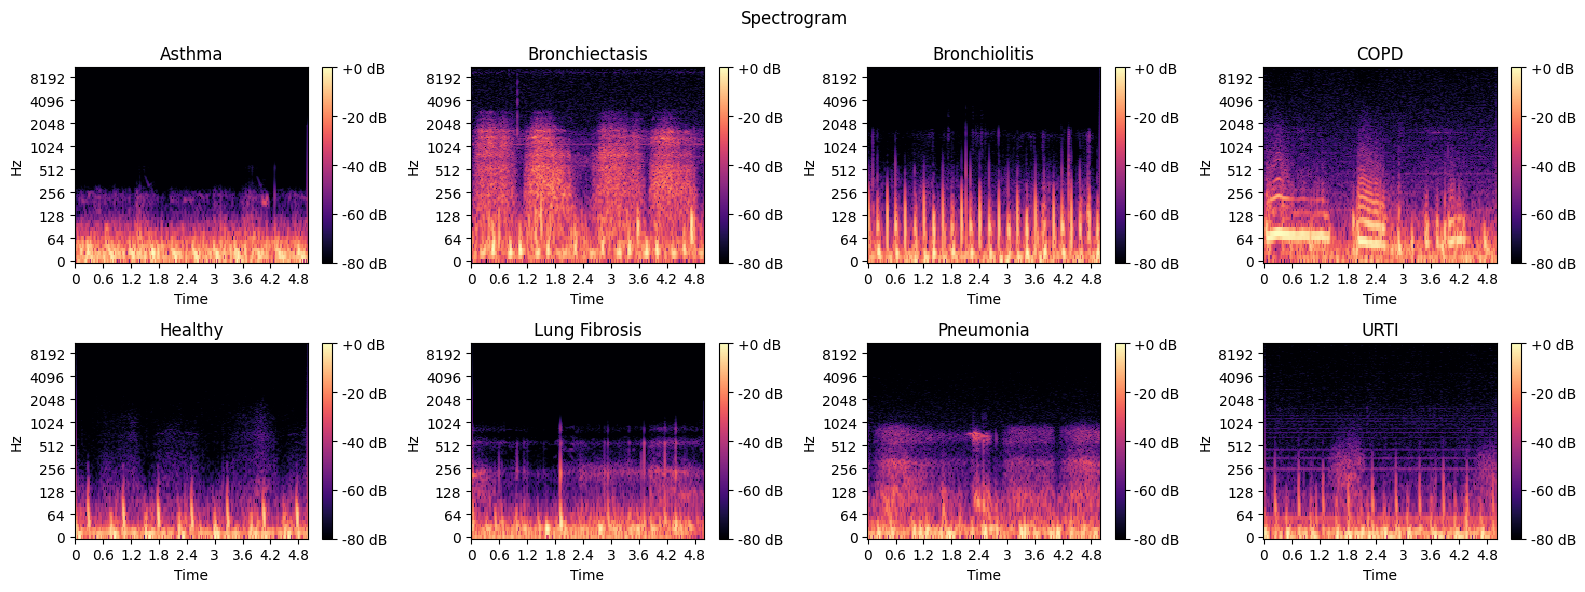

Sample shape for MelSpectrogram: (128, 216)


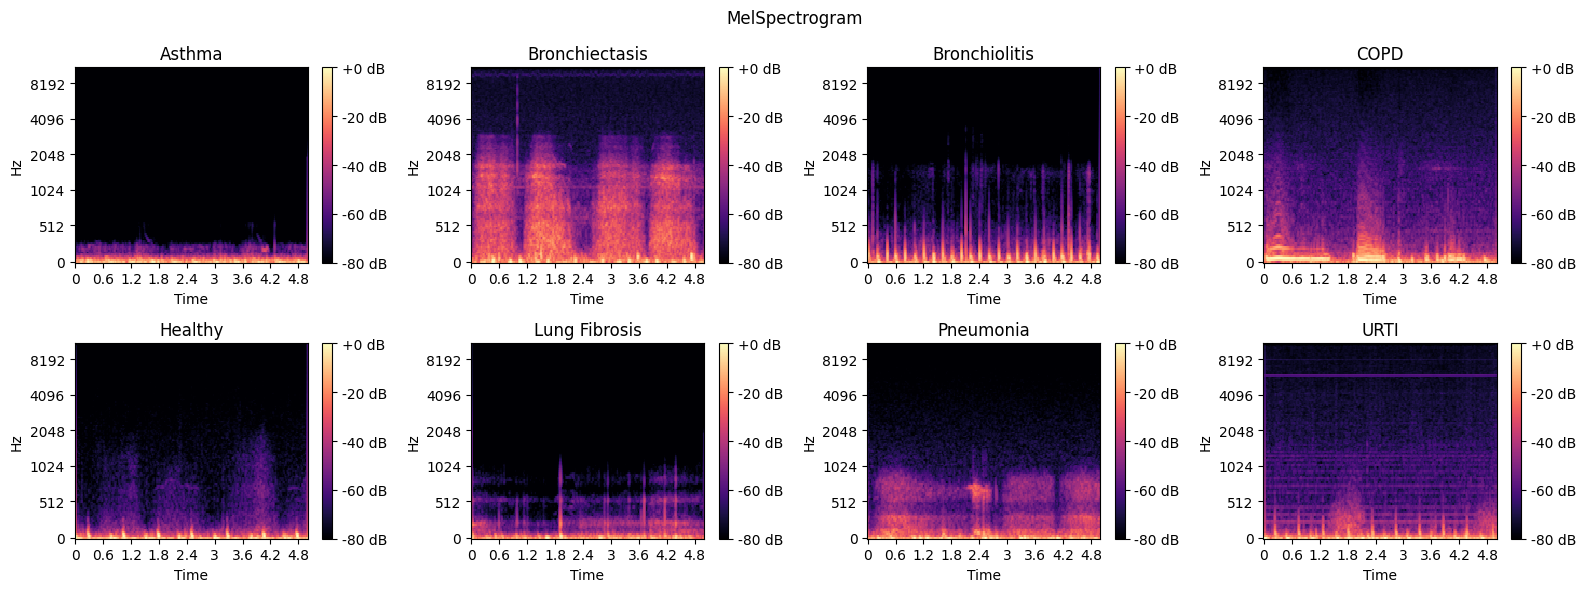

Sample shape for MFCC: (128, 216)


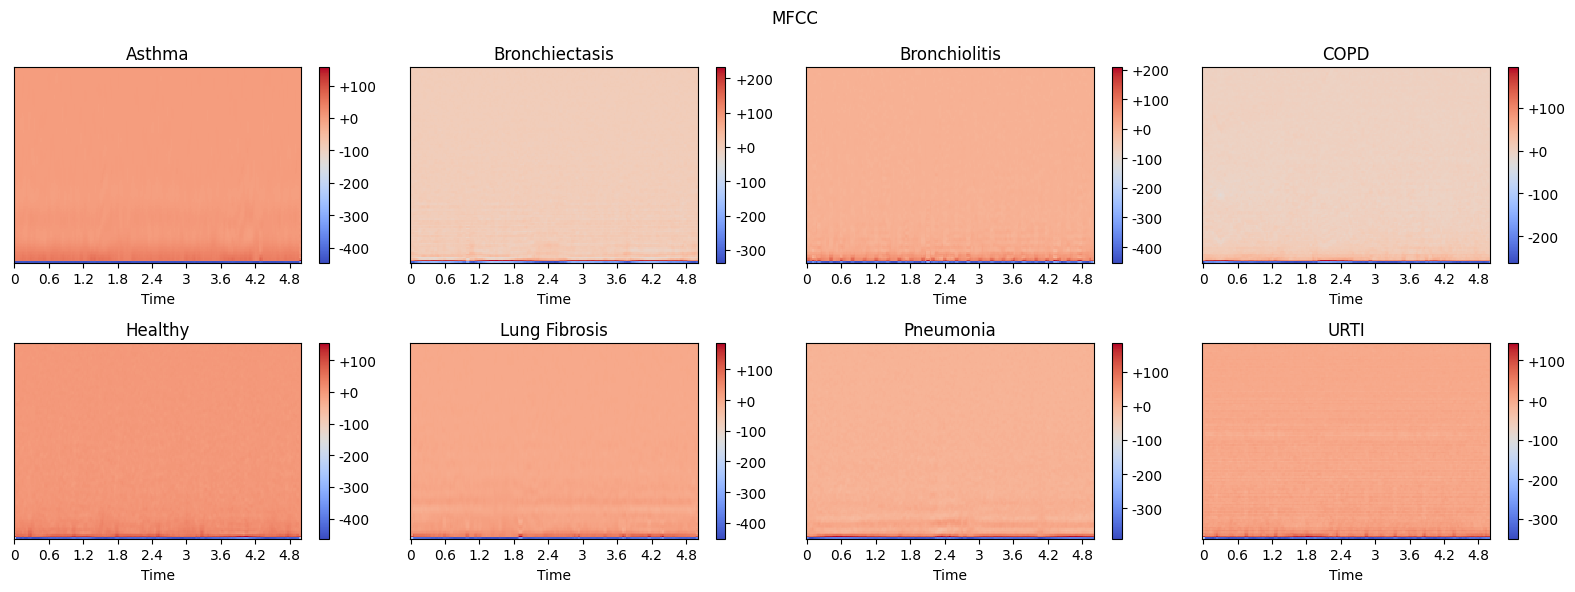

Sample shape for MFCCDelta: (128, 216)


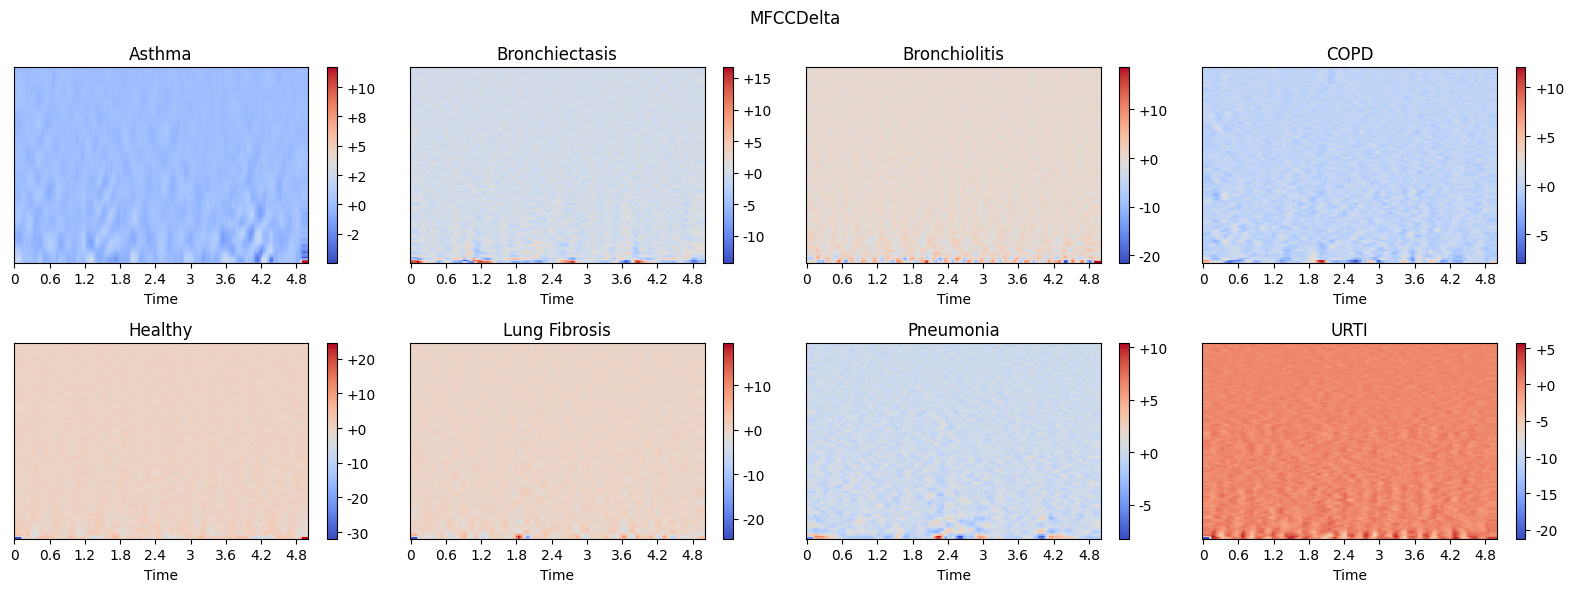

Sample shape for Chroma: (128, 216)


/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


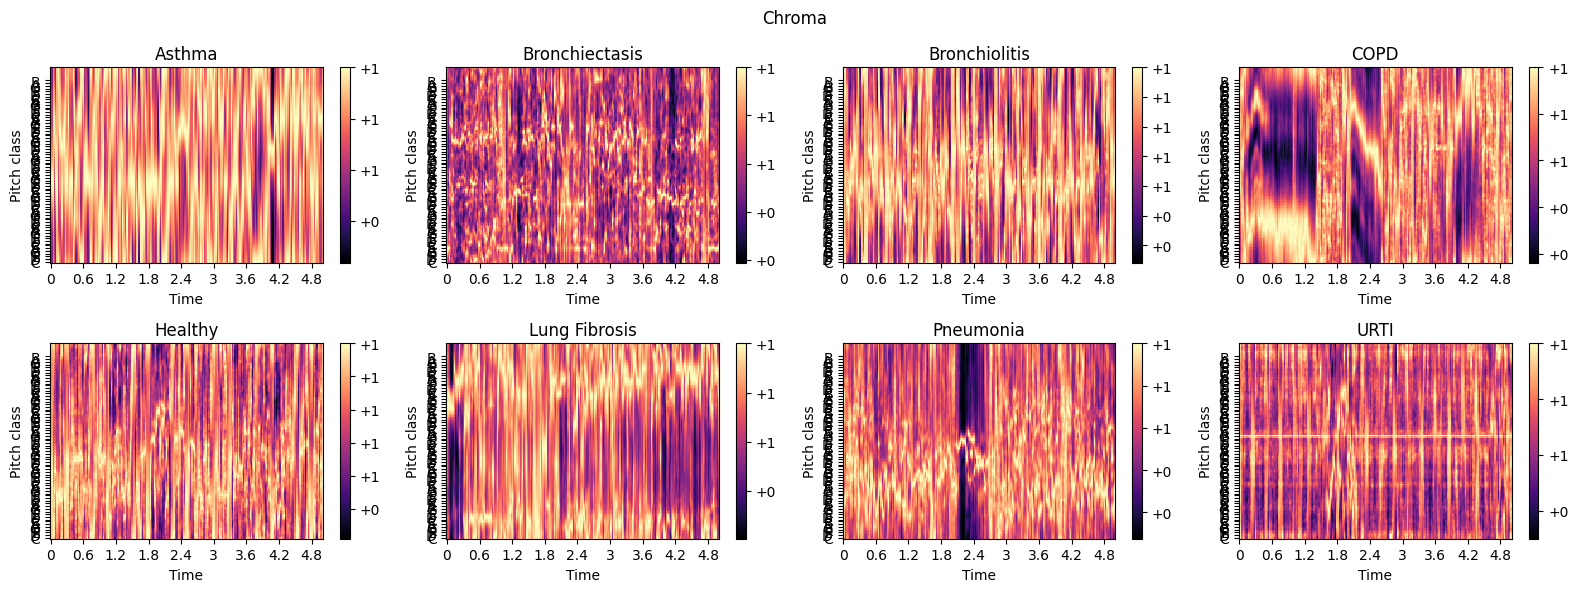

Sample shape for SpectralContrast: (5, 216)


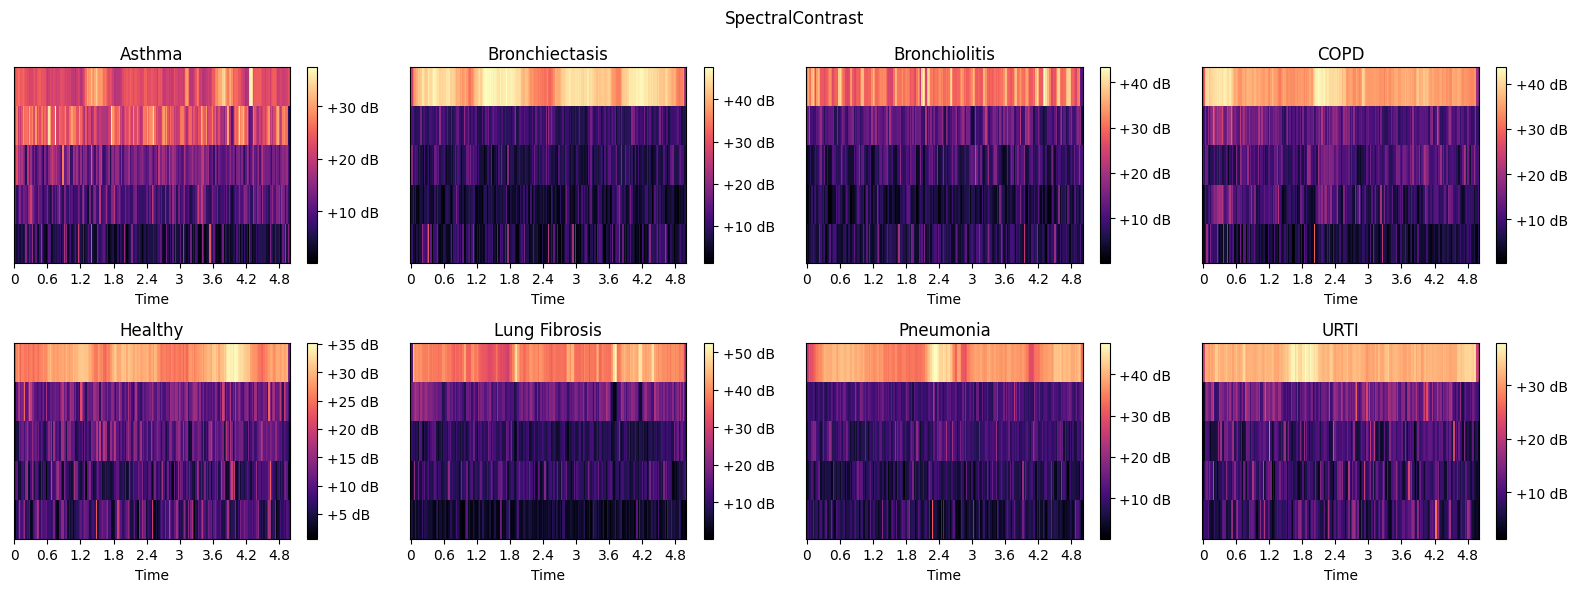

Sample shape for CQT: (48, 216)


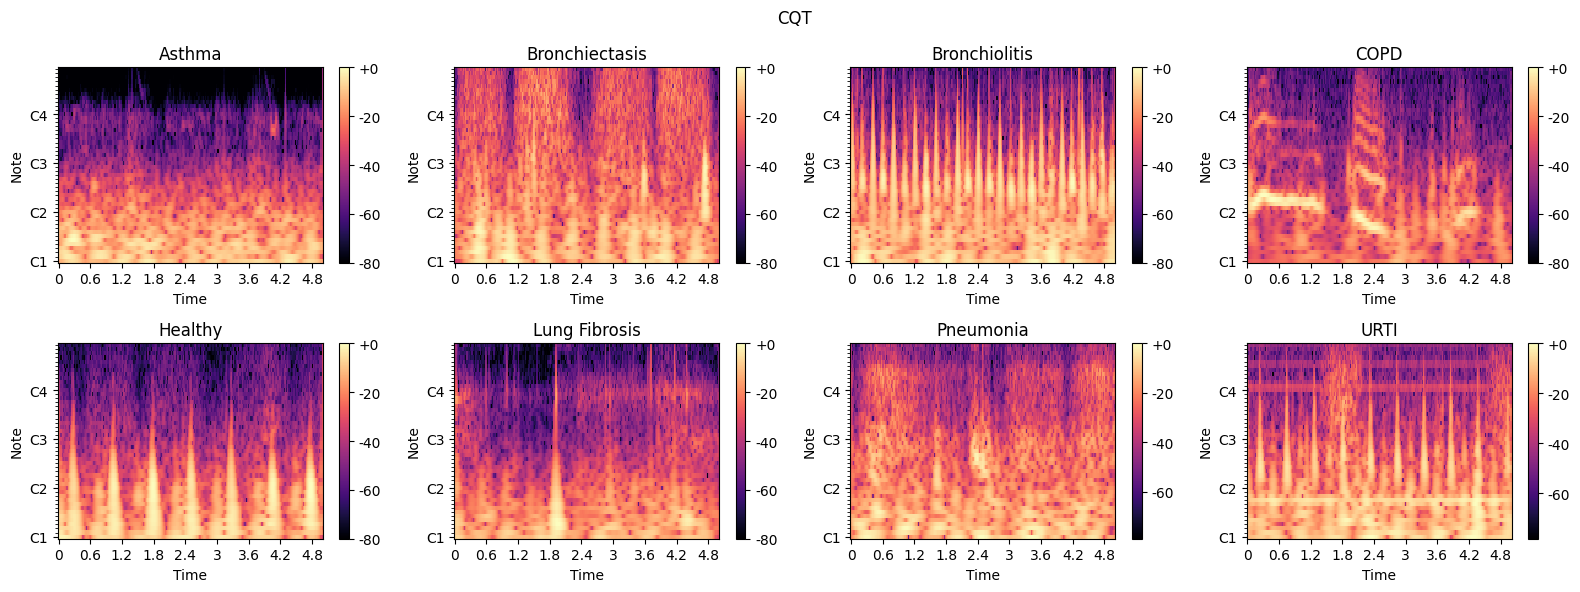

Sample shape for Phase: (1025, 216)


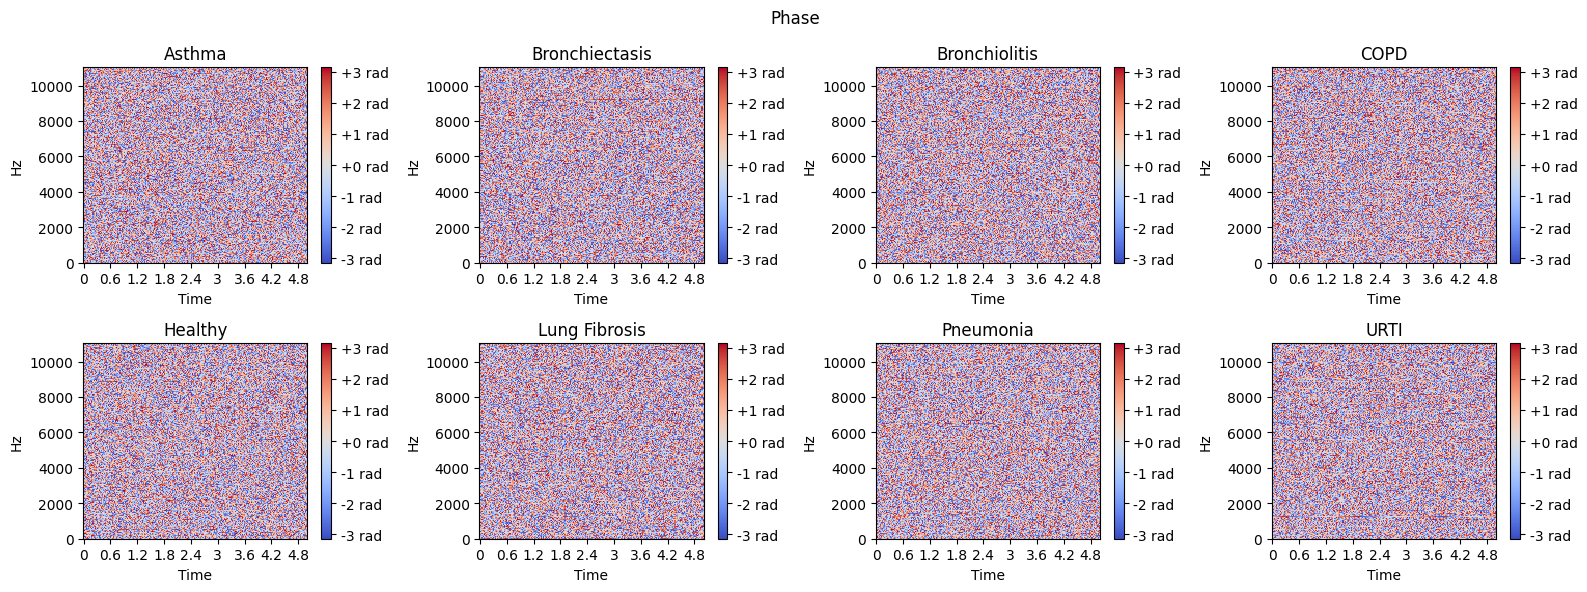

In [10]:
plot_features_by_label(DATA_FOLDER, CombinedLungSoundDataset)

Train Dataset size: 3724 samples


Diagnosis
COPD              2789
Healthy            358
Asthma             226
Pneumonia          159
URTI                72
Bronchiectasis      51
Bronchiolitis       42
Lung Fibrosis       27
Name: count, dtype: int64

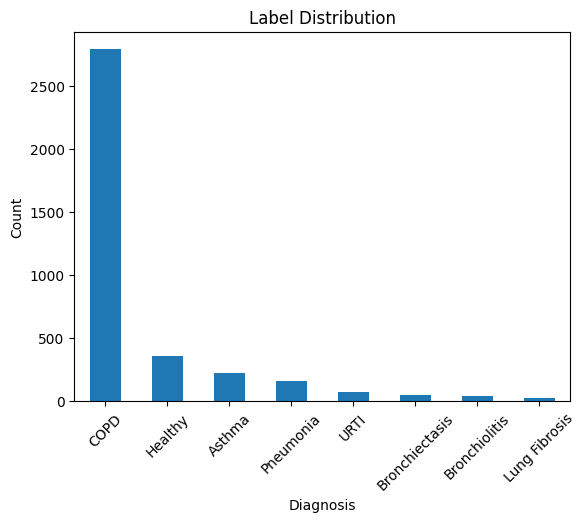

Validation Dataset size: 466 samples


Diagnosis
COPD              349
Healthy            45
Asthma             28
Pneumonia          20
URTI                9
Bronchiectasis      7
Bronchiolitis       5
Lung Fibrosis       3
Name: count, dtype: int64

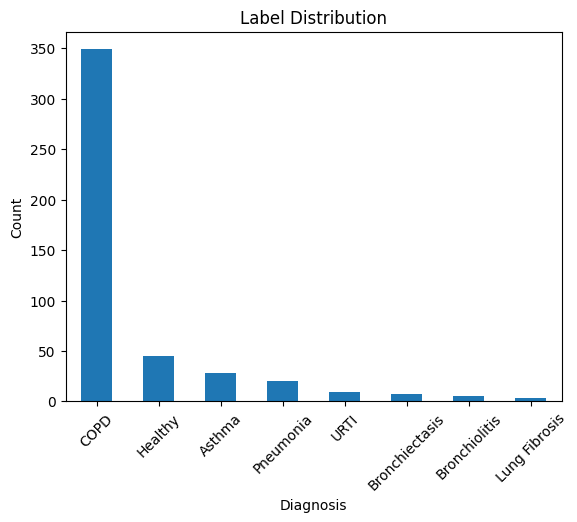

Test Dataset size: 466 samples


Diagnosis
COPD              349
Healthy            45
Asthma             29
Pneumonia          20
URTI                9
Bronchiectasis      6
Bronchiolitis       5
Lung Fibrosis       3
Name: count, dtype: int64

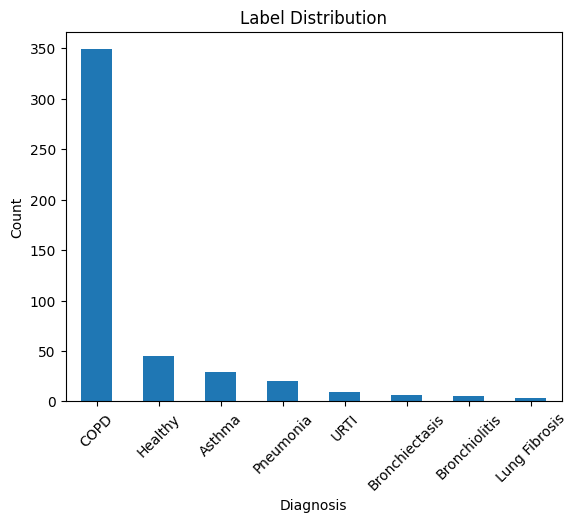

In [11]:
train_dataset = CombinedLungSoundDataset(DATA_FOLDER, "train", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Train Dataset size: {len(train_dataset)} samples")
plot_label_distribution(train_dataset)

val_dataset = CombinedLungSoundDataset(DATA_FOLDER, "val", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Validation Dataset size: {len(val_dataset)} samples")
plot_label_distribution(val_dataset)

test_dataset = CombinedLungSoundDataset(DATA_FOLDER, "test", classes=SELECTED_CLASSES, transform=data_transforms)
print(f"Test Dataset size: {len(test_dataset)} samples")
plot_label_distribution(test_dataset)